126


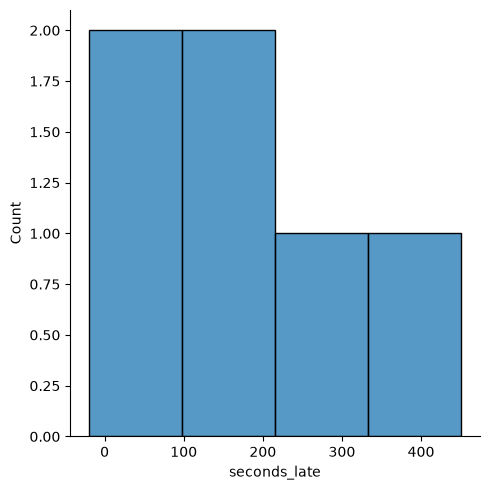

In [17]:
import seaborn
from pandas import DataFrame
import sqlite3
from datetime import datetime

con = sqlite3.connect("bus.db")

deltas = []

cur = con.cursor()
res = cur.execute("SELECT expected, actual FROM departures").fetchall()
print(len(res))

for row in res:
    
    expected = datetime.fromtimestamp(row[0])

    actual = datetime.fromtimestamp(row[1])

    if expected > datetime.now():
        continue
    # if excpected < actual -> bus came late
    delta =  (actual - expected).seconds  if expected < actual else (expected - actual).seconds * -1
    deltas.append(delta)


points = {"seconds_late" : list(filter(lambda s : abs(s) < 2000,deltas))}

df = DataFrame(data=points)
seaborn.displot(df, x="seconds_late")
